In [1]:
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
import pandas as pd
import numpy as np
import torch
import json

c:\Users\user0\llm_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Name of the pretrained or fine-tuned model to evaluate
# It can be a huggingface model or a local model path
# Examples: "./Agent_resources/Models/roberta_ds_all", "FacebookAI/roberta-base"
# The following code employs the fine-tuned model obtained from the previous notebook THE MODEL FINE-TUNING
model_name = "./Agent_resources/Models/final_finetuning"
tokenizer_sim = AutoTokenizer.from_pretrained("roberta-base")
model_sim = AutoModel.from_pretrained(model_name,output_hidden_states=True)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2067.58it/s]


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

model_sim.to(device)
model_sim.eval()

device: cuda


RobertaModel(
  (embeddings): RobertaEmbeddings(
    (word_embeddings): Embedding(50265, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
  )
  (encoder): RobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x RobertaLayer(
        (attention): RobertaAttention(
          (self): RobertaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): RobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (dropou

ID: 4eff0720836a198b6174eecf02cbfdbf
N pages: 28
Title: 第０回：授業の準備
Lecture Title: Session 0: Course Preparation
ID: 5a4be1fa34e62bb8a6ec6b91d2462f5a
N pages: 15
Title: 第７回：離散時間システム～線形時不変システム，差分方程式～
Lecture Title: Session 7: Discrete-Time Systems – Linear Time-Invariant Systems and Difference Equations
ID: 69f62956429865909921fa916d61c1f8
N pages: 19
Title: 第５回：離散時間信号とZ変換
Lecture Title: Lecture 5: Discrete-Time Signals and the Z-Transform
ID: 70f250e2d762fbde8a2e70eabf6eb953
N pages: 32
Title: 第１回：ディジタル信号処理の概要
Lecture Title: Overview of Digital Signal Processing
ID: 885b2c7a6deb4fea10f319c4ce993e02
N pages: 15
Title: 第９回：離散フーリエ変換
Lecture Title: Lecture 9: Discrete Fourier Transform
ID: 5516adb142fcb18a017c72602abbdb6d
N pages: 14
Title: 第２回：周期信号とフーリエ級数
Lecture Title: Session 2: Periodic Signals and Fourier Series
ID: 9161ab7a1b61012c4c303f10b4c16b2c
N pages: 14
Title: 第１０回：高速フーリエ変換
Lecture Title: Lecture 10: Fast Fourier Transform
ID: 81374713d991042a0e18865aa693cc24
N pages: 20
Title: 第

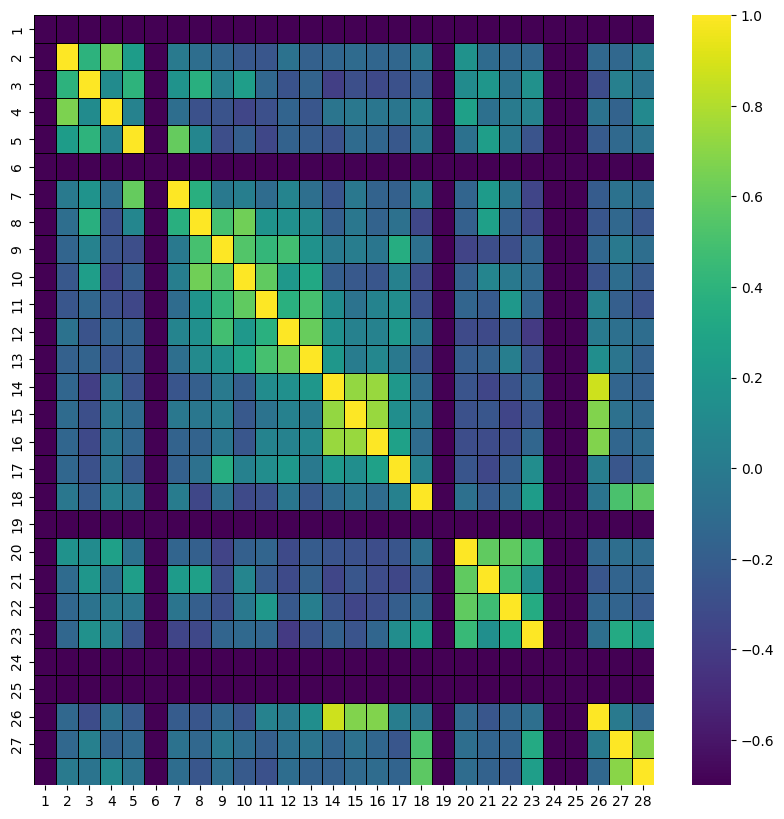

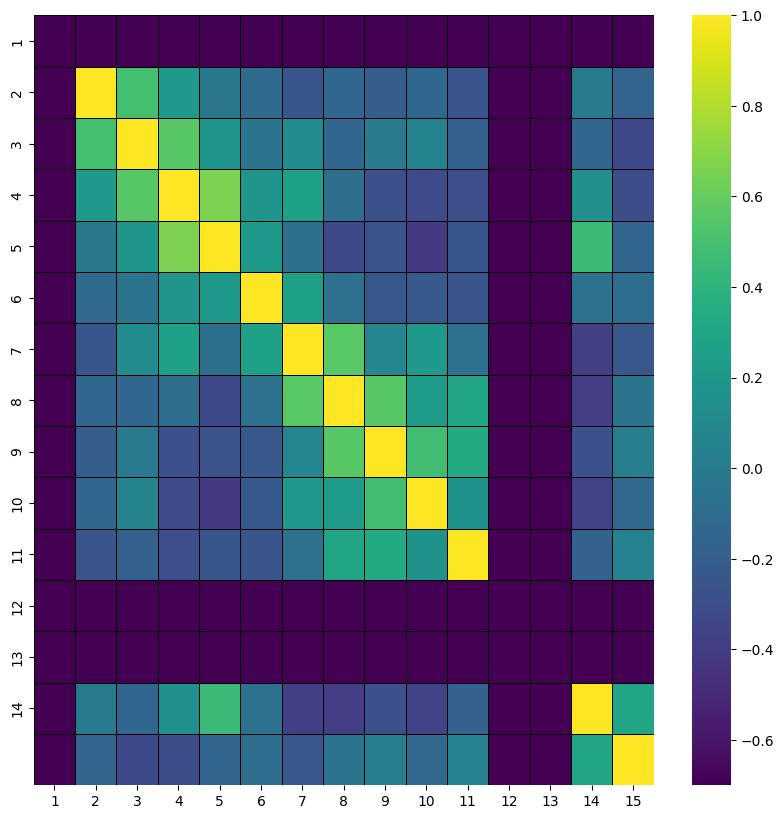

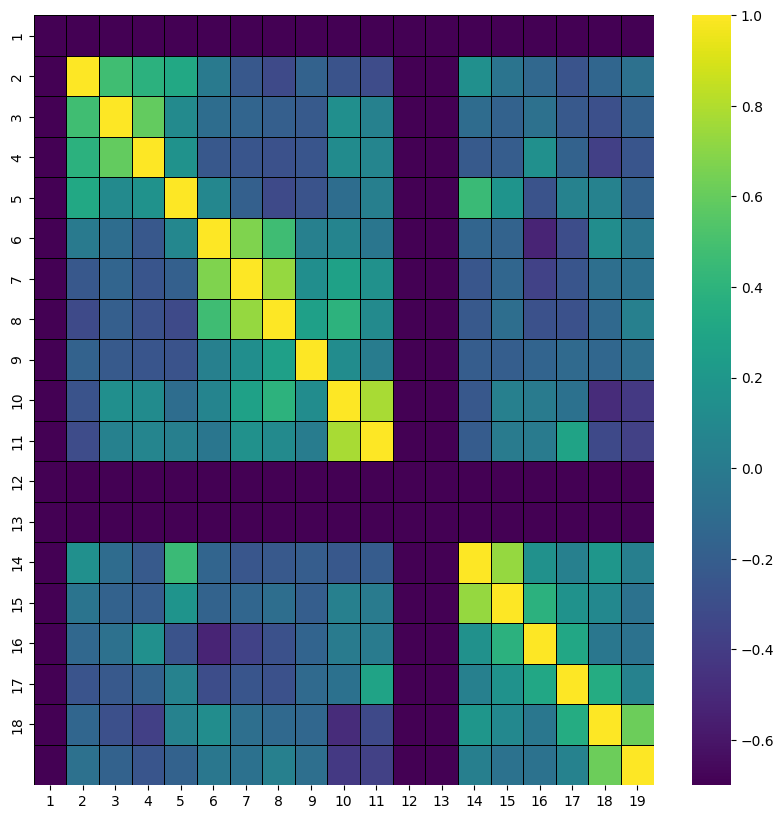

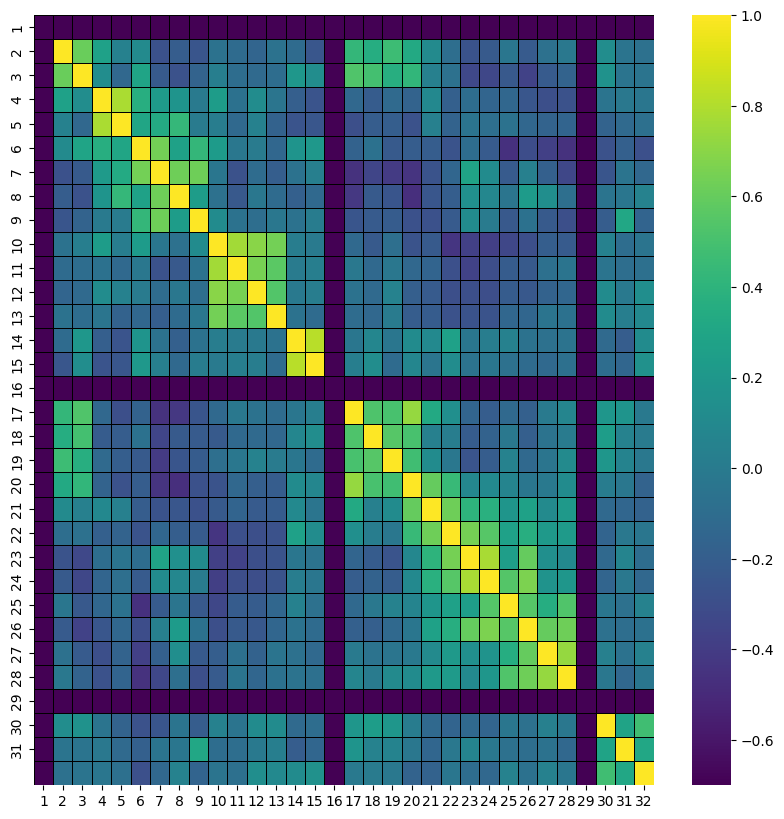

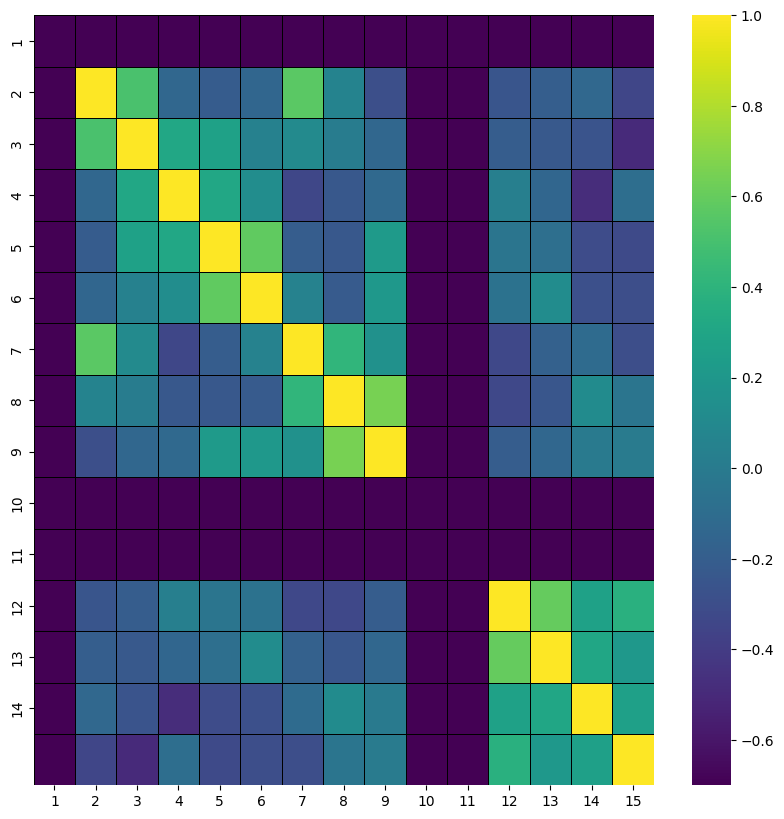

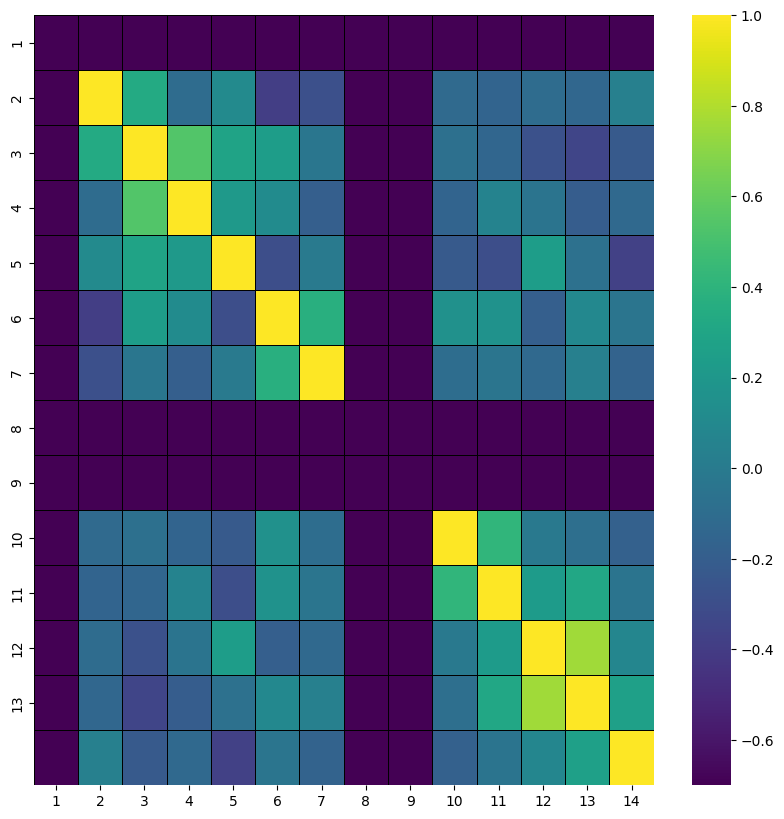

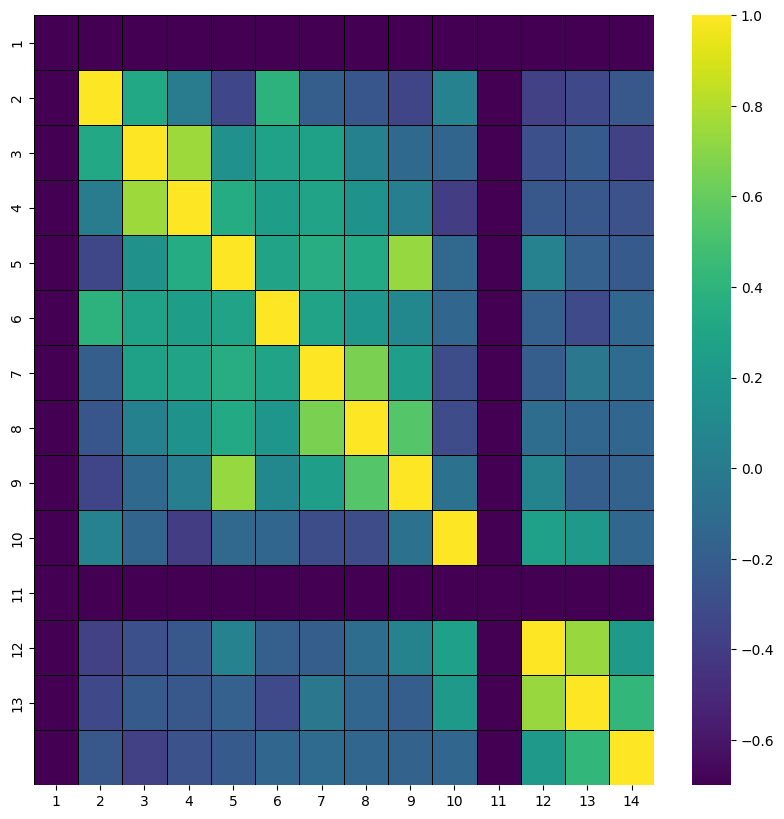

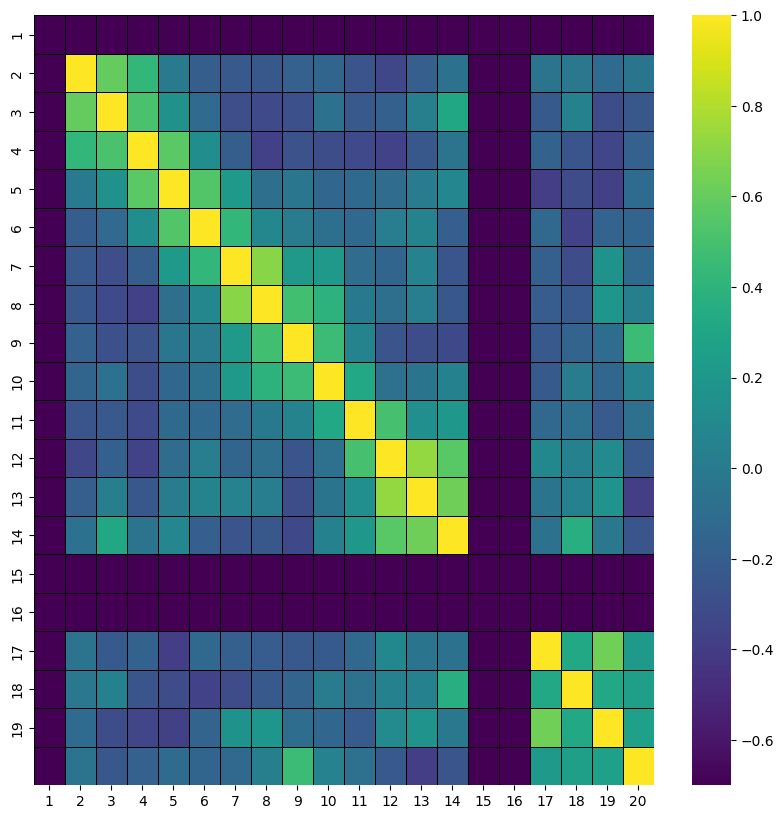

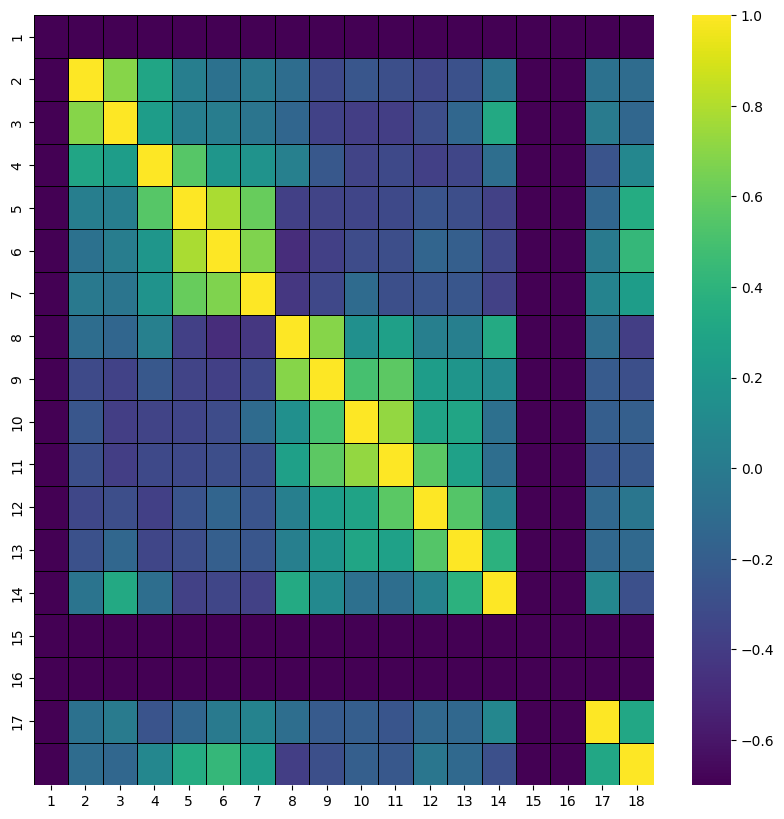

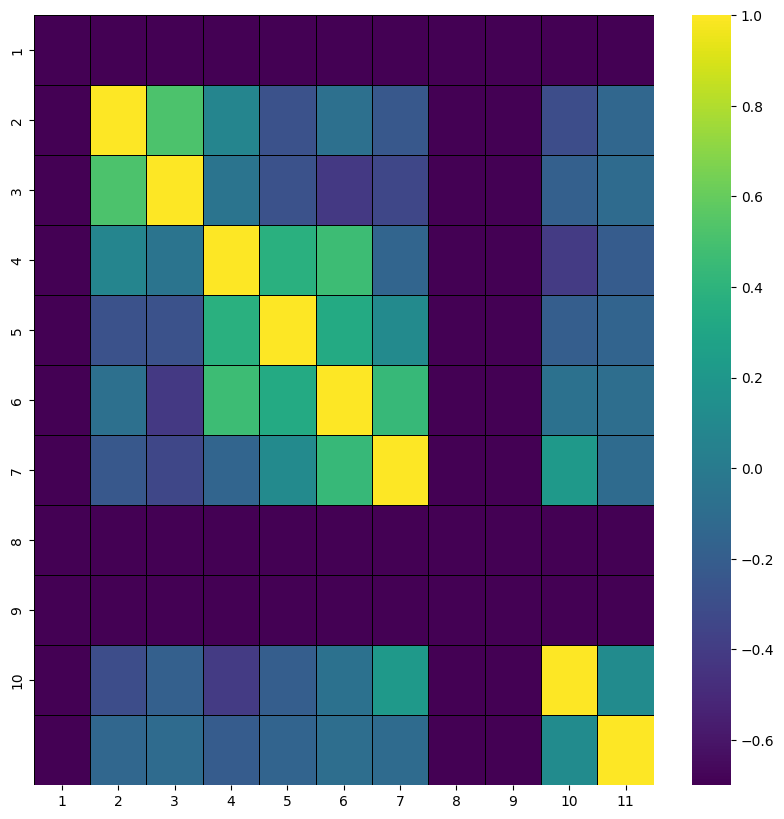

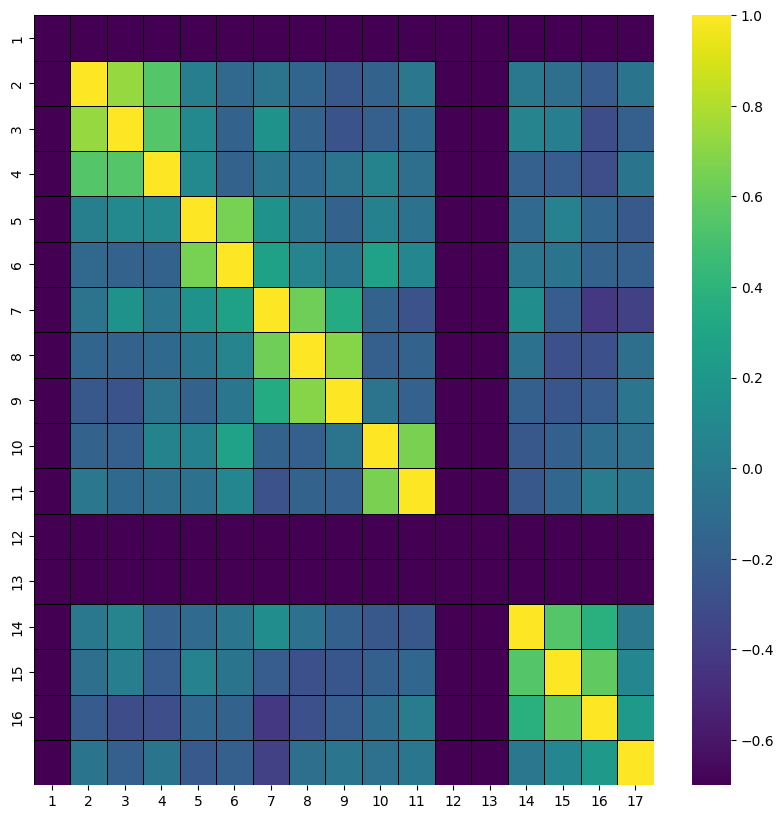

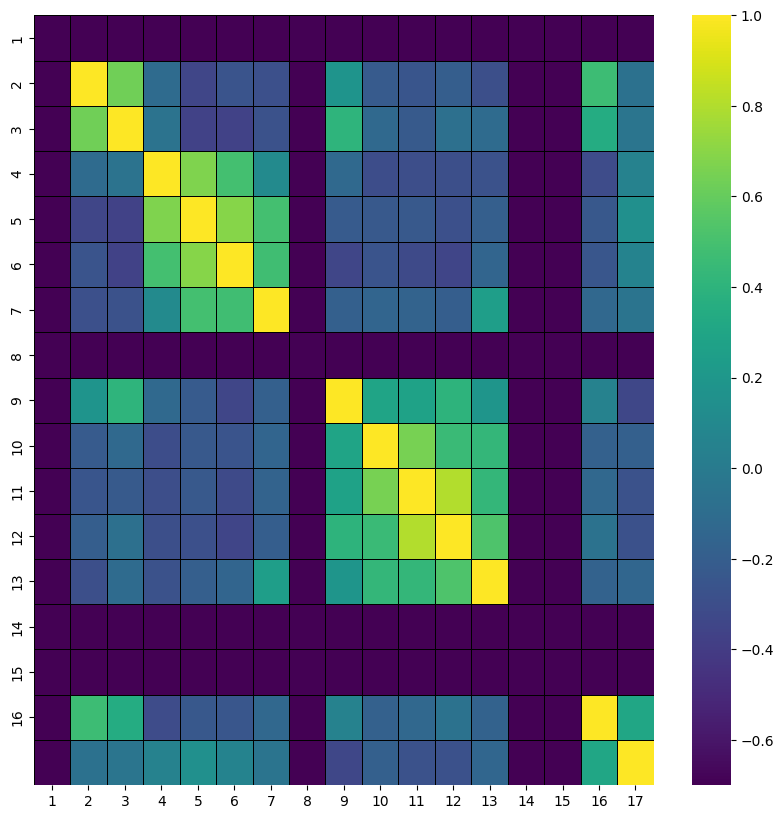

In [ ]:
# This code works for the course "Digital Signal Theory" from Kyushu University used in the experiments
# For a new course, you need to include here the information about the lecture materials included in the course (contentsid)
# the number of pages of each material (pages) and the name of the corresponding class (title)
course_id = 207
course_materials = pd.read_csv("./pid{}_material_info.csv".format(course_id))[["contentsid","pages","title"]]

for n_material in range(course_materials.shape[0]):
    material_id = course_materials["contentsid"][n_material]
    max_pages = course_materials["pages"][n_material]
    title = course_materials["title"][n_material]

    # Metadata generated in the previous notebook EXTRACT_TEXT_AND _LABELS
    with open("./Agent_resources/Titles/pid{}_{}_title.txt".format(course_id,material_id), "r", encoding="utf-8") as f:
        lecture_title = f.read()
        
    print("ID: {}".format(material_id))
    print("N pages: {}".format(max_pages))
    print("Title: {}".format(title))
    print("Lecture Title: {}".format(lecture_title))

    non_informative = ["TITLE_SLIDE","AGENDA_SLIDE","HEADER_SLIDE","CONCLUSION_SLIDE"]
    slide_types = []
    # Metadata generated in the previous notebook EXTRACT_TEXT_AND _LABELS
    with open(f"./Agent_resources/Slide_types/pid_{course_id}_{material_id}_slide_types.txt", "r") as file:
        for line in file:
            slide_types.append(line.strip())

    slide_filtered = []

    
    average_pooling_embeddings = []
    for i in range(1,max_pages+1):
        # Metadata generated in the previous notebook EXTRACT_TITLE_AND_CONTENTS
        with open("./Agent_resources/TitleC_versions/pid{}_{}_title_4_p{}.txt".format(course_id,material_id,i), "r", encoding="utf-8") as f:
            crrn_title = f.read()
        with open("./Agent_resources/TitleC_versions/pid{}_{}_body_4_p{}.txt".format(course_id,material_id,i), "r", encoding="utf-8") as f:
            crrn_body = f.read()
        
        if slide_types[i-1] in non_informative:
            slide_filtered.append(i-1)

        with torch.no_grad():
            s_tokens = tokenizer_sim(crrn_title + ":\n" + crrn_body, return_tensors='pt', truncation=True, max_length=512)
            outputs = model_sim(**s_tokens.to(device))
            embeddings = outputs.last_hidden_state[0]
            average_pooling_embeddings.append(embeddings[1:-1].mean(dim=0))

    slides_mean = torch.stack(average_pooling_embeddings)


    slides_mean = torch.nn.functional.normalize(slides_mean, p=2, dim=1)
    co_ref_mean = slides_mean@slides_mean.T

    heatmap_coref_mean = co_ref_mean.cpu().numpy()
    heatmap_coref_mean[:,slide_filtered] = -0.7
    heatmap_coref_mean[slide_filtered,:] = -0.7

    minscale = np.floor(np.min(np.where(heatmap_coref_mean == 0, np.inf, heatmap_coref_mean))* 10) / 10

    # Create the heatmap
    plt.figure(figsize=[10,10])
    ax = sns.heatmap(heatmap_coref_mean,xticklabels=np.arange(1,max_pages+1),yticklabels=np.arange(1,max_pages),cmap=plt.get_cmap("viridis"),linewidth=.5,linecolor="black",vmin=minscale)

    # Display the plot
    
    plt.savefig(f"./Agent_resources/Similarities/final_finetuning_{course_id}_{material_id}.png",dpi=300,bbox_inches="tight")

    
    np.save(f'./Agent_resources/Similarities/final_finetuning_{course_id}_{material_id}.npy', heatmap_coref_mean)